# 手写数字识别（MNIST）大作业

## 1. 第一步：导入所有需要的库

把这次项目要用到的库全部在最开头导入，这是 Python 项目的惯例。就像 ACM 开头 `#include<bits/stdc++.h>` 一样。

In [ ]:
# ==================== 基础库 ====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== 机器学习库 ====================
from sklearn.datasets import fetch_openml           # 下载 MNIST 数据集
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

# ==================== 三个模型 ====================
from sklearn.svm import SVC                          # 模型1：支持向量机
from sklearn.ensemble import RandomForestClassifier  # 模型2：随机森林
from sklearn.neural_network import MLPClassifier     # 模型3：多层感知机（神经网络）

# ==================== 数据增强用 ====================
from scipy.ndimage import rotate, shift              # 旋转、平移图片

# ==================== 画图设置 ====================
# 让 matplotlib 支持中文显示（如果系统有中文字体的话）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

print("所有库导入成功！")

所有库导入成功！


## 2. 第二步：加载 MNIST 数据集

**什么是 MNIST？** 7 万张手写数字的灰度图片，每张图 28×28 像素。

- 训练集 60000 张 → 用来让模型"学习"
- 测试集 10000 张 → 用来最后考试

我们用 `fetch_openml` 从网上下载，它会自动缓存到本地，以后就不用再下了。

In [2]:
# 从 openml 下载 MNIST 数据集（第一次会下载，之后用缓存）
print("正在加载 MNIST 数据集...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
print(f"加载完成！")

# 看一下数据长什么样
print(f"特征矩阵 X 的形状: {X.shape}")   # 应该是 (70000, 784)
print(f"标签向量 y 的形状: {y.shape}")   # 应该是 (70000,)
print(f"标签的数据类型: {y.dtype}")       # 应该是 object（字符串）
print(f"前 10 个标签: {y[:10]}")         # 看看标签长什么样

正在加载 MNIST 数据集...
加载完成！
特征矩阵 X 的形状: (70000, 784)
标签向量 y 的形状: (70000,)
标签的数据类型: object
前 10 个标签: ['5' '0' '4' '1' '9' '2' '1' '3' '1' '4']


### 2.1 类型转换

`fetch_openml` 返回的标签是**字符串**（'0'、'1'...），我们需要转成整数。像素值是 0-255 的整数，归一化之前先转成 float32。

In [3]:
# 标签：字符串 → 整数
y = y.astype(np.int32)

# 像素：整数 → float32（为归一化作准备），然后除以 255 缩放到 [0, 1]
X = X.astype(np.float32) / 255.0

print(f"标签类型: {y.dtype}, 范围: {y.min()} ~ {y.max()}")
print(f"像素类型: {X.dtype}, 范围: {X.min():.4f} ~ {X.max():.4f}")

标签类型: int32, 范围: 0 ~ 9
像素类型: float32, 范围: 0.0000 ~ 1.0000


### 2.2 划分训练集和测试集

MNIST 的 70000 张图里，前 60000 张是训练集，后 10000 张是测试集。我们就按这个约定来分。

In [4]:
# 按 MNIST 官方约定划分
X_train_full, X_test = X[:60000], X[60000:]
y_train_full, y_test = y[:60000], y[60000:]

print(f"训练集: {X_train_full.shape[0]} 张图片")
print(f"测试集: {X_test.shape[0]} 张图片")

# 对每个类别计数，看分布是否均衡
unique, counts = np.unique(y_train_full, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  数字 {u}: {c:5d} 张 ({c/len(y_train_full)*100:.1f}%)")

训练集: 60000 张图片
测试集: 10000 张图片
  数字 0:  5923 张 (9.9%)
  数字 1:  6742 张 (11.2%)
  数字 2:  5958 张 (9.9%)
  数字 3:  6131 张 (10.2%)
  数字 4:  5842 张 (9.7%)
  数字 5:  5421 张 (9.0%)
  数字 6:  5918 张 (9.9%)
  数字 7:  6265 张 (10.4%)
  数字 8:  5851 张 (9.8%)
  数字 9:  5949 张 (9.9%)


### 2.3 看看数据长什么样

这是最重要的一步。拿到数据别急着跑模型，先**用眼睛看**——图片清不清晰？数字长什么样？标签对不对？

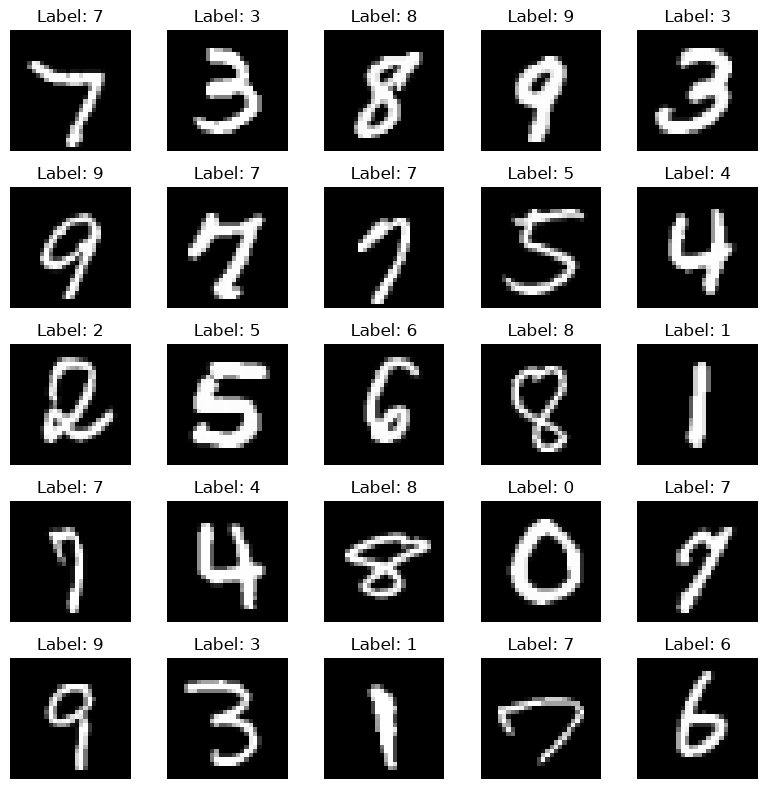

In [5]:
# 随机选 25 张图展示
np.random.seed(42)
indices = np.random.choice(len(X_train_full), 25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = X_train_full[indices[i]].reshape(28, 28)   # 784 → 28×28
    label = y_train_full[indices[i]]
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()